In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv("titanic.csv")



Data Inspection 

In [15]:
df.head()
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Removal of Duplicate entrties 

In [5]:
df=df.drop_duplicates()


Missing Values

In [6]:
df['Age'] = df['Age'].fillna(df['Age'].median())


In [16]:
df['Age'].isnull().sum()

np.int64(177)

In [7]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [8]:
df['Embarked'].isnull().sum()

np.int64(0)

Standadize Column Name

In [17]:
df.columns = df.columns.str.lower().str.strip()

In [18]:

df['sex'] = df['sex'].str.lower().str.strip()
df['embarked'] = df['embarked'].str.upper().str.strip()

Formatting The Test

In [8]:

df['pclass'] = df['pclass'].astype('category')
df['sex'] = df['sex'].astype('category')
df['embarked'] = df['embarked'].astype('category')
df['age'] = pd.to_numeric(df['age'], errors='coerce')
df['fare'] = pd.to_numeric(df['fare'], errors='coerce')
df['name'] = df['name'].astype('string')
df['ticket'] = df['ticket'].astype('string')

Data Cleaning

In [9]:
df.to_csv("titanic_cleaned.csv",index=False)

Exploratatory Data

In [10]:
df['age'].mean()

np.float64(29.36158249158249)

In [11]:

df['fare'].mode()

0    8.05
Name: fare, dtype: float64

In [12]:
df['passengerid'].mode()

0        1
1        2
2        3
3        4
4        5
      ... 
886    887
887    888
888    889
889    890
890    891
Name: passengerid, Length: 891, dtype: int64

In [19]:
df['fare'].max

<bound method Series.max of 0       7.2500
1      71.2833
2       7.9250
3      53.1000
4       8.0500
        ...   
886    13.0000
887    30.0000
888    23.4500
889    30.0000
890     7.7500
Name: fare, Length: 891, dtype: float64>

In [21]:
print(df['fare'].max())

512.3292


In [14]:
df['fare'].min

<bound method Series.min of 0       7.2500
1      71.2833
2       7.9250
3      53.1000
4       8.0500
        ...   
886    13.0000
887    30.0000
888    23.4500
889    30.0000
890     7.7500
Name: fare, Length: 891, dtype: float64>

In [15]:
df.groupby("sex")["age"].median()

sex
female    28.0
male      28.0
Name: age, dtype: float64

In [16]:
df['survived'].value_counts()

survived
0    549
1    342
Name: count, dtype: int64

Histogram

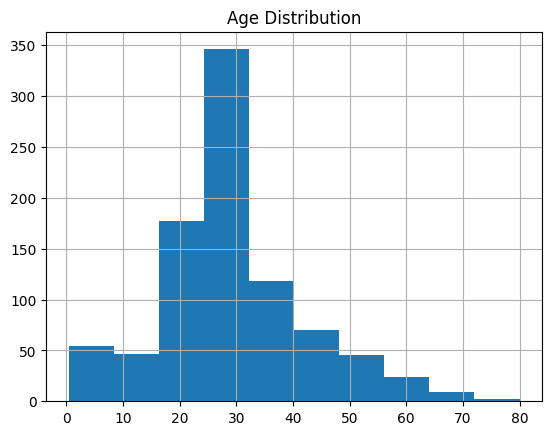

In [17]:
df["age"].hist()
plt.title("Age Distribution")
plt.show()
#he majority of travelers were aged 20 to 40 years.

#Few children under 5 and seniors over 70.

#The distribution is approximately bell-shaped with a slight leftward skew (more young adults).

#Indicates that most travelers were adults of working age

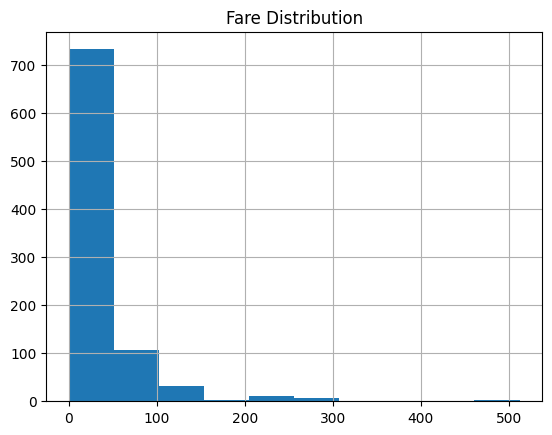

In [18]:
df["fare"].hist()
plt.title("Fare Distribution")
plt.show()
#Most travelers spent under $50.

#Only a small number of travelers spent more than $200.

#The distribution is significantly right-skewed (extended tail on the right).

#Suggests that the majority of tickets were economy or lower-class fares

Boxplot

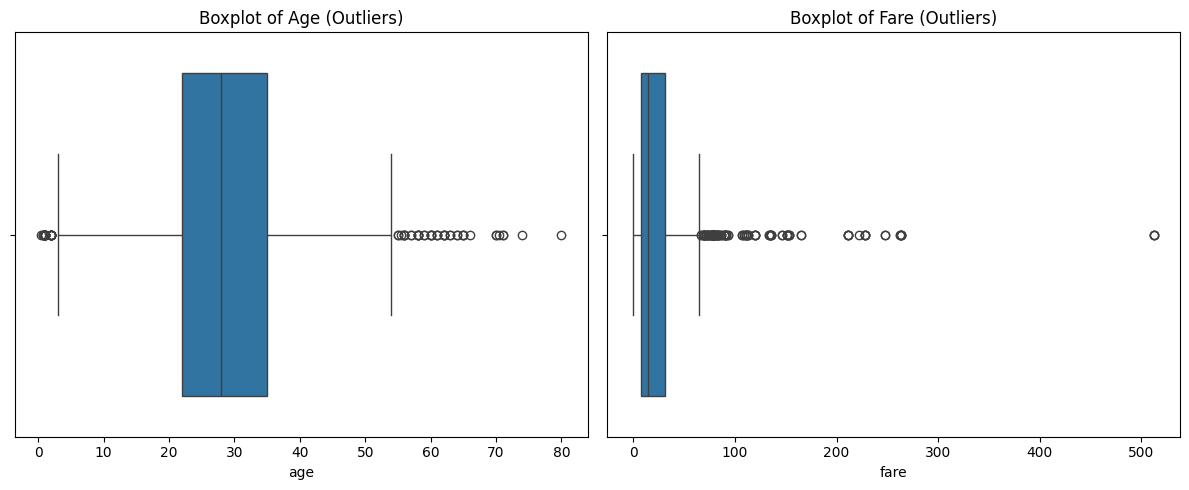

In [19]:

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.boxplot(x=df['age'])
plt.title('Boxplot of Age (Outliers)')

plt.subplot(1,2,2)
sns.boxplot(x=df['fare'])
plt.title('Boxplot of Fare (Outliers)')
plt.tight_layout()
plt.show()

Line Chart 

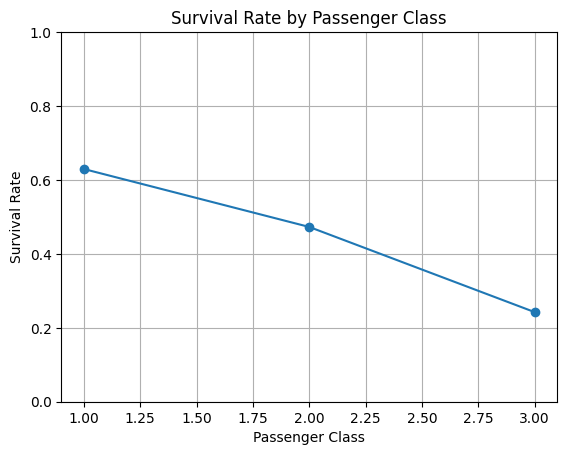

In [20]:
survival_rate = df.groupby('pclass')['survived'].mean()
plt.plot(survival_rate.index, survival_rate.values, marker='o', linestyle='-')
plt.title('Survival Rate by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')
plt.ylim(0, 1)
plt.grid(True)
plt.show()

Bar chart 

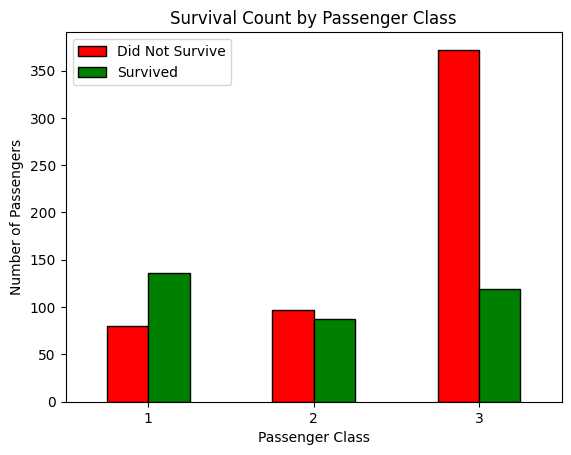

In [21]:

survival_counts = df.groupby(['pclass', 'survived']).size().unstack()
survival_counts.plot(kind='bar', stacked=False, color=['red', 'green'], edgecolor='black')
plt.title('Survival Count by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Number of Passengers')
plt.xticks(rotation=0)
plt.legend(['Did Not Survive', 'Survived'])
plt.show()

Heatmap Coorelation 

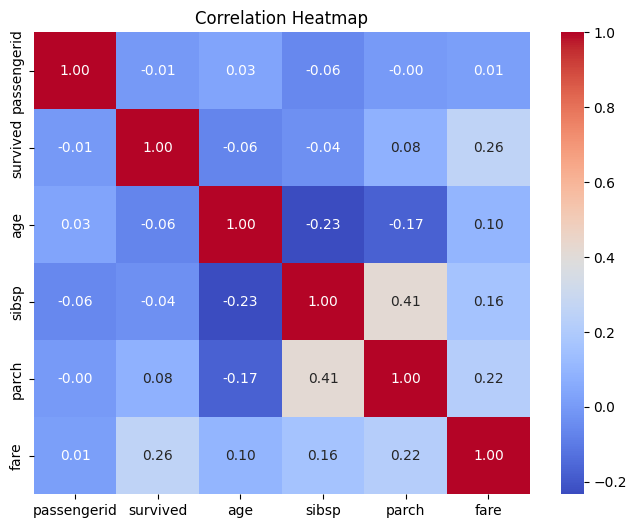

In [22]:

numeric_cols = df.select_dtypes(include=['float64', 'int64'])
plt.figure(figsize=(8,6))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

Data Inspection
891 rows, 12 columns.

Missing values: Age (177), Cabin (687), Embarked (2).

Missing Values
Age filled with median (28).

Embarked filled with mode ('S').

Data Cleaning
No duplicates.

Converted Pclass, Sex, Embarked to category; Name, Ticket to string.

Exploratory Data (Summary Statistics)
Mean age: 29.7 years.

Survival rate: 38.4% (342 survived, 549 did not).

Histogram – Age Distribution
Most passengers 20–40 years old.

Few children under 5 or seniors over 70.

Histogram – Fare Distribution
Most fares under $50.

Long tail of high fares (max $512).

Right‑skewed.

Boxplot – Age & Fare Outliers
Age: few outliers above 65.

Fare: many high‑fare outliers (>$100).

Line Chart – Survival Rate by Passenger Class
1st class: ~63%

2nd class: ~47%

3rd class: ~24%

The higher the class (lower numeric value), the better the survival chance.

Bar Chart – Survival Count by Passenger Class
3rd class had the most passengers but the fewest survivors.

Heatmap – Correlation Analysis
Pclass vs Fare: -0.55 (strong negative).

Fare vs Survived: ~0.26 (weak positive).

Age vs Survived: ~0.08 (no correlation).

Summary
Majority young adults with low fares – economy‑class base.

Survival drops sharply with class – privilege matters.

Higher fare weakly linked to survival; age has almost no correlation.

Wealth (fare) determines class, which drives survival.

Class and wealth are stronger predictors than age or family size.

